# Capitulo 4 — Regresion

Este notebook acompaña al capitulo 4 del libro *IA para Estudiantes de Ciencias*.
Implementa los modelos de regresion presentados en el texto sobre datos de
**propiedades moleculares** y dedica una seccion completa a **procesos gaussianos**
con seleccion de nucleo y cuantificacion de incertidumbre sobre un conjunto de
datos de **energias de adsorcion en catalizadores**.

Modelos cubiertos:

1. Regresion lineal y polinomial (Ridge)
2. Maquinas de vectores soporte para regresion (SVR con nucleo RBF)
3. Bosques aleatorios (Random Forest) con importancia de variables
4. Procesos gaussianos: seleccion de nucleo y cuantificacion de incertidumbre

Todos los conjuntos de datos se generan de forma sintetica y reproducible
(semilla fija), de modo que el notebook se ejecuta sin descargar ficheros externos.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, WhiteKernel, ConstantKernel as C
)

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (6, 4)


## Datos de propiedades moleculares

Generamos un conjunto sintetico con varias descriptores moleculares
(peso molecular, area polar superficial, numero de donantes/aceptores de
enlace de hidrogeno, logP, numero de enlaces rotables) y una propiedad
objetivo continua (por ejemplo, una energia o solubilidad). La relacion
incluye terminos no lineales para que los modelos mas flexibles puedan
mostrar su ventaja.


In [2]:
n = 600
nombres_variables = [
    "peso_molecular", "area_polar", "n_donantes", "n_aceptores",
    "logP", "n_enlaces_rotables", "n_anillos", "fraccion_sp3"
]

PM   = rng.uniform(100, 500, n)
APSA = rng.uniform(10, 150, n)
ND   = rng.integers(0, 6, n).astype(float)
NA   = rng.integers(0, 10, n).astype(float)
logP = rng.normal(2.0, 1.5, n)
NER  = rng.integers(0, 12, n).astype(float)
NAN  = rng.integers(0, 5, n).astype(float)
FSP3 = rng.uniform(0, 1, n)

X = np.column_stack([PM, APSA, ND, NA, logP, NER, NAN, FSP3])

# Propiedad objetivo con dependencia no lineal + ruido
y = (
    0.012 * PM
    - 0.03 * APSA
    + 0.4 * logP**2
    - 0.5 * np.sqrt(APSA)
    + 0.8 * ND
    - 0.2 * NA
    + 1.5 * np.sin(0.02 * PM)
    + rng.normal(0, 0.5, n)
)
# Centrar el objetivo para facilitar el ajuste de los modelos
y = (y - y.mean()) / y.std()

df = pd.DataFrame(X, columns=nombres_variables)
df["objetivo"] = y
df.head()


,peso_molecular,area_polar,n_donantes,n_aceptores,logP,n_enlaces_rotables,n_anillos,fraccion_sp3,objetivo
0,409.582419,76.850822,0.0,7.0,5.401466,8.0,1.0,0.110750,2.059637
1,275.551376,116.600559,3.0,6.0,0.453924,3.0,1.0,0.079506,-1.495654
2,443.439168,136.465902,4.0,9.0,2.105629,10.0,1.0,0.750836,-0.079041
3,378.947212,110.897433,3.0,9.0,0.235700,3.0,0.0,0.292936,-0.536695
4,137.670939,144.849571,2.0,7.0,0.833591,6.0,2.0,0.889302,-2.093775


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print("Entrenamiento:", X_train.shape, " Test:", X_test.shape)


Entrenamiento: (450, 8)  Test: (150, 8)


## 1. Regresion lineal y polinomial

Se encadenan en un `Pipeline` tres etapas: expansion polinomial de las
caracteristicas, estandarizacion y un ajuste Ridge. Comparar varios grados
mediante validacion cruzada permite identificar el que minimiza el error de
generalizacion, medido con la raiz del error cuadratico medio (RMSE).


In [4]:
for grado in [1, 2, 3, 5]:
    pipe = Pipeline([
        ("poly",   PolynomialFeatures(degree=grado, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model",  Ridge(alpha=1.0))
    ])
    rmse = -cross_val_score(pipe, X_train, y_train, cv=5,
                            scoring="neg_root_mean_squared_error")
    print(f"Grado {grado}: RMSE = {rmse.mean():.4f} +- {rmse.std():.4f}")


Grado 1: RMSE = 0.3830 +- 0.0423
Grado 2: RMSE = 0.2697 +- 0.0078
Grado 3: RMSE = 0.2842 +- 0.0121
Grado 5: RMSE = 0.3701 +- 0.0278


## 2. Maquinas de vectores soporte para regresion (SVR)

La SVR es sensible a la escala, por lo que `StandardScaler` es obligatorio.
Buscamos los hiperparametros C, epsilon y gamma mediante validacion cruzada.


In [5]:
pipe_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

param_grid = {
    "svr__C":       [1, 10, 100, 1000],
    "svr__epsilon": [0.01, 0.05, 0.1],
    "svr__gamma":   ["scale", 0.01, 0.05, 0.1],
}
gs = GridSearchCV(pipe_svr, param_grid, cv=5,
                  scoring="neg_root_mean_squared_error",
                  n_jobs=-1)
gs.fit(X_train, y_train)

from sklearn.metrics import r2_score
y_pred_svr = gs.predict(X_test)

print("Mejores hiperparametros:", gs.best_params_)
print("RMSE validacion:", -gs.best_score_)
print("R2 test:", r2_score(y_test, y_pred_svr))


Mejores hiperparametros: {'svr__C': 100, 'svr__epsilon': 0.1, 'svr__gamma': 0.05}
RMSE validacion: 0.23547189191021484
R2 test: 0.9607795253986388


## 3. Bosques aleatorios (Random Forest)

El Random Forest combina muchos arboles entrenados sobre muestras bootstrap
con seleccion aleatoria de variables. El error *out-of-bag* (OOB) ofrece una
estimacion gratuita del error de generalizacion, y la importancia de variables
ayuda a interpretar el modelo.


In [6]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_features="sqrt",      # seleccion aleatoria de variables
    min_samples_leaf=2,       # evita hojas con un solo punto
    oob_score=True,           # error out-of-bag (gratis!)
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

print(f"R2 OOB (estimacion gratuita): {rf.oob_score_:.4f}")
print(f"R2 test (evaluacion honesta): {rf.score(X_test, y_test):.4f}")

importancias = pd.Series(rf.feature_importances_,
                         index=nombres_variables).sort_values(ascending=False)
print("\nTop variables mas importantes:")
print(importancias.head(10))


R2 OOB (estimacion gratuita): 0.8167
R2 test (evaluacion honesta): 0.7949

Top variables mas importantes:
area_polar            0.317274
logP                  0.241791
peso_molecular        0.211039
n_donantes            0.084838
fraccion_sp3          0.048954
n_aceptores           0.041260
n_enlaces_rotables    0.032266
n_anillos             0.022578
dtype: float64


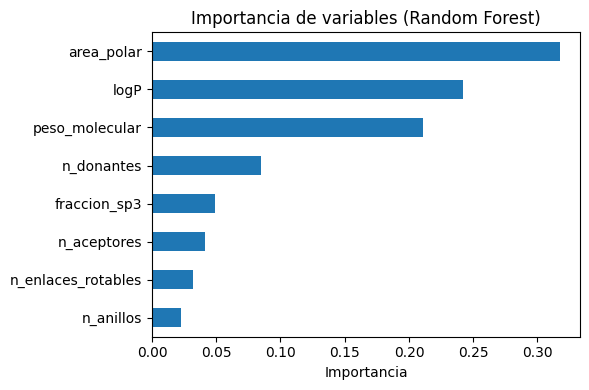

In [7]:
fig, ax = plt.subplots()
importancias.sort_values().plot.barh(ax=ax)
ax.set_xlabel("Importancia")
ax.set_title("Importancia de variables (Random Forest)")
plt.tight_layout()
plt.show()


## 4. Procesos gaussianos: energias de adsorcion en catalizadores

En el diseno de catalizadores, el espacio de aleaciones candidatas es enorme y
cada calculo de la energia de adsorcion (por DFT) es costoso, de modo que solo
se dispone de unas pocas decenas de observaciones. El proceso gaussiano (GP) es
idoneo en este regimen de datos escasos porque, ademas de predecir, **cuantifica
la incertidumbre** de cada prediccion.

Generamos un conjunto pequeno de energias de adsorcion en funcion de descriptores
del catalizador (por ejemplo, el centro de la banda d y el numero de coordinacion).


In [8]:
m = 80  # pocas observaciones, regimen tipico de DFT
centro_banda_d = rng.uniform(-3.0, 0.0, m)     # eV
num_coordinacion = rng.uniform(6, 12, m)

Xc = np.column_stack([centro_banda_d, num_coordinacion])

# Energia de adsorcion (eV) con relacion no lineal tipo volcan + ruido pequeno
E_ads = (
    -0.8 * (centro_banda_d + 1.5)**2
    + 0.15 * num_coordinacion
    - 1.2
    + rng.normal(0, 0.08, m)
)

Xc_train, Xc_test, Ec_train, Ec_test = train_test_split(
    Xc, E_ads, test_size=0.30, random_state=42
)
print("Train:", Xc_train.shape, " Test:", Xc_test.shape)


Train: (56, 2)  Test: (24, 2)


### Seleccion de nucleo

Definimos un nucleo compuesto: una amplitud (`ConstantKernel`) por un nucleo
**Matern** con nu = 5/2 (opcion por defecto robusta, funciones dos veces
diferenciables) mas un `WhiteKernel` que modela el ruido. Los hiperparametros se
optimizan por maxima verosimilitud marginal con varios reinicios para evitar
minimos locales.


In [9]:
kernel = C(1.0, (1e-2, 1e2)) \
       * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) \
       + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e1))

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,  # varias inits para evitar minimos locales
    normalize_y=True,
    random_state=42
)

pipe_gp = Pipeline([
    ("scaler", StandardScaler()),
    ("gp",     gp)
])
pipe_gp.fit(Xc_train, Ec_train)

# Prediccion con incertidumbre
y_pred, y_std = pipe_gp.predict(Xc_test, return_std=True)

print(f"Hiperparametros optimizados: {pipe_gp.named_steps['gp'].kernel_}")
print(f"R2 test: {pipe_gp.score(Xc_test, Ec_test):.4f}")
print(f"Incertidumbre media: {y_std.mean():.4f}")


Hiperparametros optimizados: 10**2 * Matern(length_scale=7.96, nu=2.5) + WhiteKernel(noise_level=0.0131)
R2 test: 0.9684
Incertidumbre media: 0.0939


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


### Cuantificacion de incertidumbre y calibracion

Si la incertidumbre esta bien estimada, alrededor del 95 % de los valores reales
deberian caer dentro del intervalo de confianza `y_pred +- 1.96 * sigma`.


In [10]:
cobertura = np.mean(np.abs(Ec_test - y_pred) < 1.96 * y_std)
print(f"Cobertura IC 95%: {cobertura:.3f}  (ideal: 0.950)")


Cobertura IC 95%: 0.917  (ideal: 0.950)


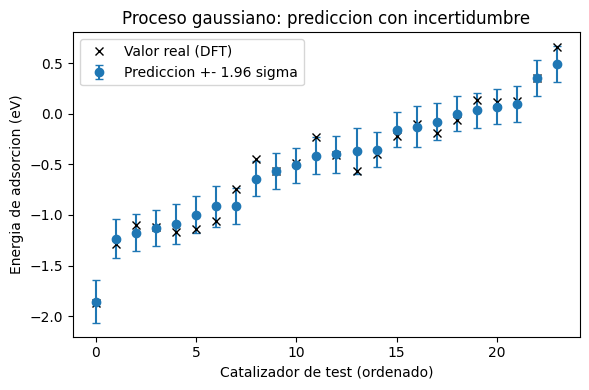

In [11]:
orden = np.argsort(y_pred)
fig, ax = plt.subplots()
idx = np.arange(len(y_pred))
ax.errorbar(idx, y_pred[orden], yerr=1.96 * y_std[orden],
            fmt="o", capsize=3, label="Prediccion +- 1.96 sigma")
ax.plot(idx, Ec_test[orden], "x", color="black", label="Valor real (DFT)")
ax.set_xlabel("Catalizador de test (ordenado)")
ax.set_ylabel("Energia de adsorcion (eV)")
ax.set_title("Proceso gaussiano: prediccion con incertidumbre")
ax.legend()
plt.tight_layout()
plt.show()


## Resumen

- La **regresion lineal/Ridge** ofrece un modelo interpretable y robusto al
  sobreajuste; con expansion polinomial captura no linealidades suaves.
- La **SVR** con nucleo RBF es eficaz en conjuntos moderados, pero requiere
  estandarizacion y ajuste cuidadoso de C, epsilon y gamma.
- El **Random Forest** es flexible, ofrece estimacion OOB gratuita e importancia
  de variables interpretable.
- El **proceso gaussiano** es la herramienta de eleccion en el regimen de datos
  escasos (energias de adsorcion calculadas por DFT) porque cuantifica la
  incertidumbre, lo que habilita estrategias de diseno activo de catalizadores.
